In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
import plotly.express as px
import shap
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')
import sys
import os
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
sys.path.append(os.path.abspath(".."))

from models.scaling import scale_features

from config import load_data, FEATURES, SKEWED, FRAUD_IDS
df, client_data = load_data(activity_state=2)

X_std = scale_features(scaler_type="standard", data=client_data)
X_rob = scale_features(scaler_type="robust", data=client_data)

### Standart Scaler

In [ ]:
check = client_data.copy()

for nn in [10, 20, 30, 40, 50]:
    for c in [0.01, 0.02, 0.05, 0.1]:
        lof = LocalOutlierFactor(
                n_neighbors=nn,
                contamination=c,
                metric='minkowski',
                p=2
            )
        y_pred = lof.fit_predict(X_std)
        check[f"lof_label_std_{nn}_{c}"] = y_pred
        check[f"lof_score_std_{nn}_{c}"] = lof.negative_outlier_factor_
        hit_rate_lof = check[check['is_fraud']][f'lof_label_std_{nn}_{c}'].value_counts(normalize=True).get(-1, 0)
        print(f"Hit rate for n_neighbors={nn} and contamination={c}: {hit_rate_lof:.4f}")

Hit rate for n_neighbors=10 and contamination=0.01: 0.6250  
Hit rate for n_neighbors=10 and contamination=0.02: 0.7500  
Hit rate for n_neighbors=10 and contamination=0.05: 0.8750  
Hit rate for n_neighbors=10 and contamination=0.1: 1.0000  
Hit rate for n_neighbors=20 and contamination=0.01: 0.5000  
Hit rate for n_neighbors=20 and contamination=0.02: 0.7500  
Hit rate for n_neighbors=20 and contamination=0.05: 1.0000  
Hit rate for n_neighbors=20 and contamination=0.1: 1.0000  
Hit rate for n_neighbors=30 and contamination=0.01: 0.7500  
Hit rate for n_neighbors=30 and contamination=0.02: 0.8750  
Hit rate for n_neighbors=30 and contamination=0.05: 1.0000  
Hit rate for n_neighbors=30 and contamination=0.1: 1.0000  
Hit rate for n_neighbors=40 and contamination=0.01: 0.7500  
Hit rate for n_neighbors=40 and contamination=0.02: 0.8750  
Hit rate for n_neighbors=40 and contamination=0.05: 1.0000  
Hit rate for n_neighbors=40 and contamination=0.1: 1.0000  
Hit rate for n_neighbors=50 and contamination=0.01: 0.7500  
Hit rate for n_neighbors=50 and contamination=0.02: 1.0000 best  
Hit rate for n_neighbors=50 and contamination=0.05: 1.0000  
Hit rate for n_neighbors=50 and contamination=0.1: 1.0000  

In [66]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

lof = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.02,
    metric='minkowski',
    p=2
)

y_pred = lof.fit_predict(X_std)

client_data["lof_label_std"] = y_pred
client_data["lof_score_std"] = lof.negative_outlier_factor_

hit_rate_lof_std = client_data[client_data['is_fraud']][f'lof_label_std'].value_counts(normalize=True).get(-1, 0)
print(f"Hit rate for n_neighbors=50 and contamination=0.02: {hit_rate_lof_std:.4f}")

Hit rate for n_neighbors=50 and contamination=0.02: 1.0000


In [78]:
FRAUD_IDS

[11968000,
 11970409,
 11726701,
 14827913,
 12411311,
 12412748,
 11812494,
 12396334]

In [89]:
pid = 11726701

k = 50
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_rob)

distances, indices = nn.kneighbors(X_rob)

i = X_rob.index.get_loc(pid)

neighbor_ids = X_rob.index[indices[i]]
neighbors = client_data.loc[neighbor_ids]

row = client_data[client_data.index == pid]

diff = np.round((row[FEATURES].values[0] - neighbors[FEATURES].mean().values)/neighbors[FEATURES].mean().values*100, 2)
result_df = pd.DataFrame({
    "diff": diff,
    "row": row[FEATURES].values[0],
    "neighbors": neighbors[FEATURES].mean().values
}, index=FEATURES)

result_df.sort_values("diff", key=abs, ascending=False)

,diff,row,neighbors
first_second_trn_diff,-93.75,14.023333,224.465950
time_between_trn_median,-92.21,22.821111,292.840675
first_third_trn_diff,-83.90,96.350278,598.475394
first_last_trn_diff,-46.01,5610.253889,10390.906672
bonuses_used_sum,44.66,1160.000000,801.900000
num_of_waiters,-33.46,7.000000,10.520000
gross_amount_sum,30.65,17886.000000,13689.728000
share_bonus_trn,-30.00,0.153846,0.219778
share_bonus_after_first,-29.54,0.160000,0.227080
bonuses_accum_sum,29.08,1658.000000,1284.460000


In [ ]:
pid = 11970409

k = 50
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_rob)

distances, indices = nn.kneighbors(X_rob)

i = X_rob.index.get_loc(pid)

neighbor_ids = X_rob.index[indices[i]]
neighbors = client_data.loc[neighbor_ids]

row = client_data[client_data.index == pid]

diff = row[FEATURES].values[0] - neighbors[FEATURES].mean().values
result_df = pd.DataFrame({
    "diff": diff,
    "row": row[FEATURES].values[0],
    "neighbors": neighbors[FEATURES].mean().values
}, index=FEATURES)

result_df.sort_values("diff", key=abs, ascending=False)

,diff,row,neighbors
gross_amount_sum,13435.053800,24924.600000,11489.546200
first_last_trn_diff,-2614.789933,387.264167,3002.054100
bonuses_accum_sum,2074.940000,3193.000000,1118.060000
bonuses_used_sum,-316.680000,37.000000,353.680000
gross_amount_max,-207.441200,3532.500000,3739.941200
first_third_trn_diff,-187.607561,0.171389,187.778950
first_second_trn_diff,-103.783772,0.157500,103.941272
gross_amount_mean,-72.015223,1186.885714,1258.900938
time_between_trn_median,-62.758506,1.806528,64.565033
num_of_trn,10.660000,21.000000,10.340000


In [82]:
from sklearn.neighbors import NearestNeighbors

pid = 11968000

k = 50
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_rob)

distances, indices = nn.kneighbors(X_rob)

i = X_rob.index.get_loc(pid)

neighbor_ids = X_rob.index[indices[i]]
neighbors = client_data.loc[neighbor_ids]

row = client_data[client_data.index == pid]

diff = row[FEATURES].values[0] - neighbors[FEATURES].mean().values
result_df = pd.DataFrame({
    "diff": diff,
    "row": row[FEATURES].values[0],
    "neighbors": neighbors[FEATURES].mean().values
}, index=FEATURES)

result_df.sort_values("diff", key=abs, ascending=False)

,diff,row,neighbors
gross_amount_sum,50676.077600,69564.600000,18888.522400
first_last_trn_diff,-7581.579506,653.309167,8234.888672
bonuses_accum_sum,6802.140000,8625.000000,1822.860000
bonuses_used_sum,-1028.920000,130.000000,1158.920000
first_third_trn_diff,-635.234883,0.045278,635.280161
first_second_trn_diff,-406.438261,0.018611,406.456872
gross_amount_mean,220.172599,1086.946875,866.774276
time_between_trn_median,-213.483947,1.909722,215.393669
gross_amount_max,56.436800,2970.900000,2914.463200
num_of_trn,38.740000,64.000000,25.260000


### Robust Scaler

In [14]:

for nn in [10, 20, 30, 40, 50]:
    for c in [0.01, 0.02, 0.05, 0.1]:
        lof = LocalOutlierFactor(
                n_neighbors=nn,
                contamination=c,
                metric='minkowski',
                p=2
            )
        y_pred = lof.fit_predict(X_rob)
        client_data[f"lof_label_rob_{nn}_{c}"] = y_pred
        client_data[f"lof_score_rob_{nn}_{c}"] = lof.negative_outlier_factor_
        hit_rate_lof = client_data[client_data['is_fraud']][f'lof_label_rob_{nn}_{c}'].value_counts(normalize=True).get(-1, 0)
        print(f"Hit rate for n_neighbors={nn} and contamination={c}: {hit_rate_lof:.4f}")

Hit rate for n_neighbors=10 and contamination=0.01: 0.2500
Hit rate for n_neighbors=10 and contamination=0.02: 0.3750
Hit rate for n_neighbors=10 and contamination=0.05: 0.7500
Hit rate for n_neighbors=10 and contamination=0.1: 0.8750
Hit rate for n_neighbors=20 and contamination=0.01: 0.3750
Hit rate for n_neighbors=20 and contamination=0.02: 0.7500
Hit rate for n_neighbors=20 and contamination=0.05: 0.7500
Hit rate for n_neighbors=20 and contamination=0.1: 0.8750
Hit rate for n_neighbors=30 and contamination=0.01: 0.5000
Hit rate for n_neighbors=30 and contamination=0.02: 0.7500
Hit rate for n_neighbors=30 and contamination=0.05: 0.8750
Hit rate for n_neighbors=30 and contamination=0.1: 0.8750
Hit rate for n_neighbors=40 and contamination=0.01: 0.5000
Hit rate for n_neighbors=40 and contamination=0.02: 0.6250
Hit rate for n_neighbors=40 and contamination=0.05: 0.8750
Hit rate for n_neighbors=40 and contamination=0.1: 1.0000
Hit rate for n_neighbors=50 and contamination=0.01: 0.5000
H

Hit rate for n_neighbors=10 and contamination=0.01: 0.2500  
Hit rate for n_neighbors=10 and contamination=0.02: 0.3750  
Hit rate for n_neighbors=10 and contamination=0.05: 0.7500  
Hit rate for n_neighbors=10 and contamination=0.1: 0.8750  
Hit rate for n_neighbors=20 and contamination=0.01: 0.3750  
Hit rate for n_neighbors=20 and contamination=0.02: 0.7500  
Hit rate for n_neighbors=20 and contamination=0.05: 0.7500  
Hit rate for n_neighbors=20 and contamination=0.1: 0.8750  
Hit rate for n_neighbors=30 and contamination=0.01: 0.5000  
Hit rate for n_neighbors=30 and contamination=0.02: 0.7500  
Hit rate for n_neighbors=30 and contamination=0.05: 0.8750  
Hit rate for n_neighbors=30 and contamination=0.1: 0.8750  
Hit rate for n_neighbors=40 and contamination=0.01: 0.5000  
Hit rate for n_neighbors=40 and contamination=0.02: 0.6250  
Hit rate for n_neighbors=40 and contamination=0.05: 0.8750  
Hit rate for n_neighbors=40 and contamination=0.1: 1.0000  
Hit rate for n_neighbors=50 and contamination=0.01: 0.5000  
Hit rate for n_neighbors=50 and contamination=0.02: 0.6250  
Hit rate for n_neighbors=50 and contamination=0.05: 0.8750  
Hit rate for n_neighbors=50 and contamination=0.1: 1.0000  

In [16]:
lof = LocalOutlierFactor(
    n_neighbors=40,
    contamination=0.1,
    metric='minkowski',
    p=2
)

y_pred = lof.fit_predict(X_rob)

client_data["lof_label_rob"] = y_pred
client_data["lof_score_rob"] = lof.negative_outlier_factor_

hit_rate_lof_rob = client_data[client_data['is_fraud']][f'lof_label_rob'].value_counts(normalize=True).get(-1, 0)
print(f"Hit rate for n_neighbors=50 and contamination=0.02: {hit_rate_lof_rob:.4f}")

Hit rate for n_neighbors=50 and contamination=0.02: 1.0000


In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [19]:
client_data.shape

(87748, 102)

In [20]:
outliers = client_data[client_data["lof_label_std"] == -1]
normals = client_data[client_data["lof_label_std"] == 1]

N_NORMAL = min(5000, len(normals))

viz_df = pd.concat(
    [outliers, normals.sample(n=N_NORMAL, random_state=42)],
    axis=0
)

X_viz = X_std.loc[viz_df.index]

In [21]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X_viz)

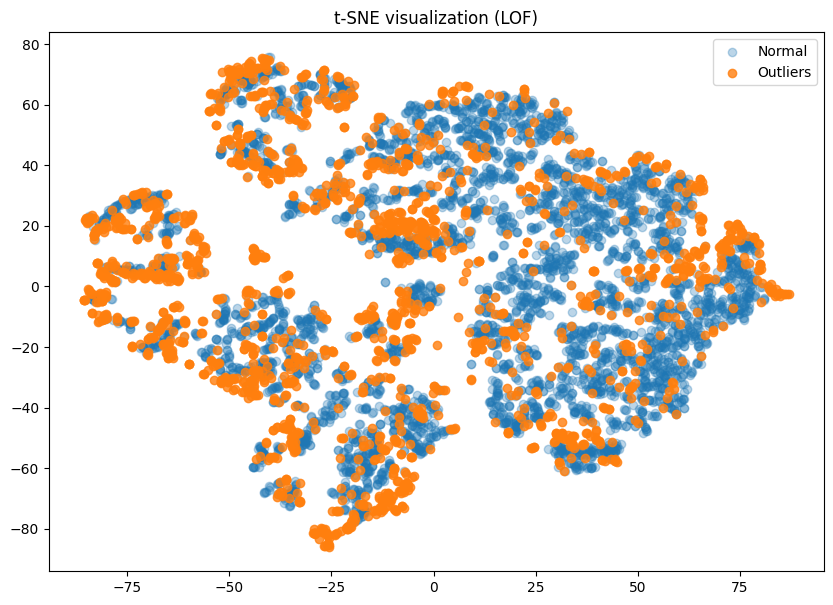

In [22]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[viz_df["lof_label_rob"] == 1, 0],
    X_tsne[viz_df["lof_label_rob"] == 1, 1],
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    X_tsne[viz_df["lof_label_rob"] == -1, 0],
    X_tsne[viz_df["lof_label_rob"] == -1, 1],
    alpha=0.8,
    label="Outliers"
)

plt.legend()
plt.title("t-SNE visualization (LOF)")
plt.show()

In [31]:
X_std = X_std.copy()
X_std.index = client_data.index

# 1) Семпл для t-SNE (бо повільно на великому датасеті)
outliers = client_data[client_data["lof_label_std"] == -1]
normals  = client_data[client_data["lof_label_std"] == 1]

N_NORMAL = min(10000, len(normals))

viz_df = pd.concat(
    [outliers, normals],
    axis=0
)

X_viz = X_std.loc[viz_df.index]


In [32]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    n_iter=1000,
    init="pca"
)

X_tsne = tsne.fit_transform(X_viz)

In [33]:
plot_df = viz_df.copy()
plot_df["tsne_1"] = X_tsne[:, 0]
plot_df["tsne_2"] = X_tsne[:, 1]

plot_df["lof_label_name"] = np.where(plot_df["lof_label_std"] == -1, "Outlier", "Normal")

In [ ]:
fig = px.scatter(
    plot_df,
    x="tsne_1",
    y="tsne_2",
    color="lof_label_name",
    hover_data=["person_id"] if "person_id" in plot_df.columns else None,
    opacity=0.1,
    title="t-SNE 2D (LOF labels)"
)

fig.update_layout(
    legend_title_text="Label",
    xaxis_title="t-SNE 1",
    yaxis_title="t-SNE 2"
)

fig.show()

In [ ]:
X_std = X_std.copy()
X_std.index = client_data.index

# 1) Семпл для t-SNE (бо повільно на великому датасеті)
outliers = client_data[client_data["lof_label_std"] == -1]
normals  = client_data[client_data["lof_label_std"] == 1]

N_NORMAL = min(10000, len(normals))
viz_df = pd.concat([outliers, normals.sample(N_NORMAL, random_state=42)])

# viz_df = pd.concat(
#     [outliers, normals],
#     axis=0
# )

X_viz = X_std.loc[viz_df.index]



tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    n_iter=1000,
    init="pca"
)

X_tsne = tsne.fit_transform(X_viz)

plot_df = viz_df.copy()
plot_df["tsne_1"] = X_tsne[:, 0]
plot_df["tsne_2"] = X_tsne[:, 1]

plot_df["lof_label_name"] = np.where(plot_df["lof_label_std"] == -1, "Outlier", "Normal")

In [ ]:
fig = px.scatter(
    plot_df,
    x="tsne_1",
    y="tsne_2",
    color=viz_df["lof_label_rob"].map({1:"Normal", -1:"Outlier"}),
    # color=plot_df["lof_score_std"],
    hover_data=["person_id"] if "person_id" in plot_df.columns else None,
    opacity=0.5,
    title="t-SNE 2D (LOF labels)"
)
fig.update_layout(
    legend_title_text="Label",
    xaxis_title="t-SNE 1",
    yaxis_title="t-SNE 2"
)

fig.show()

In [62]:
X_std = X_std.copy()
X_std.index = client_data.index

outliers = client_data[client_data["lof_label_std"] == -1]
normals  = client_data[client_data["lof_label_std"] == 1]

N_NORMAL = min(10000, len(normals))
viz_df = pd.concat([outliers, normals.sample(N_NORMAL, random_state=42)])

X_viz = X_std.loc[viz_df.index]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    # init="pca",/
    learning_rate=auto,
    random_state=42,
    n_iter=1000,
    init="pca"
)

X_tsne = tsne.fit_transform(X_viz)

plot_df = viz_df.copy()
plot_df["tsne_1"] = X_tsne[:, 0]
plot_df["tsne_2"] = X_tsne[:, 1]

plot_df["lof_label_name"] = np.where(plot_df["lof_label_std"] == -1, "Outlier", "Normal")

fig = px.scatter(
    plot_df,
    x="tsne_1",
    y="tsne_2",
    color=viz_df["lof_label_rob"].map({1:"Normal", -1:"Outlier"}),
    # color=plot_df["lof_score_std"],
    hover_data=["person_id"] if "person_id" in plot_df.columns else None,
    opacity=0.5,
    title="t-SNE 2D (LOF labels)"
)
fig.update_layout(
    legend_title_text="Label",
    xaxis_title="t-SNE 1",
    yaxis_title="t-SNE 2"
)

fig.show()

In [51]:
X_std = X_std.copy()
X_std.index = client_data.index

outliers = client_data[client_data["lof_label_std"] == -1]
normals  = client_data[client_data["lof_label_std"] == 1]

N_NORMAL = min(30000, len(normals))
viz_df = pd.concat([outliers, normals.sample(N_NORMAL, random_state=42)])

X_viz = X_std.loc[viz_df.index]



tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    n_iter=1000,
    init="pca"
)

X_tsne = tsne.fit_transform(X_viz)

plot_df = viz_df.copy()
plot_df["tsne_1"] = X_tsne[:, 0]
plot_df["tsne_2"] = X_tsne[:, 1]
plot_df["tsne_3"] = X_tsne[:, 2]

plot_df["lof_label_name"] = np.where(plot_df["lof_label_std"] == -1, "Outlier", "Normal")

In [55]:
fig = px.scatter_3d(
    plot_df,
    x="tsne_1", y="tsne_2", z="tsne_3",
    color="lof_label_name",
    opacity=0.1,
    hover_data=["person_id"] if "person_id" in plot_df.columns else None
)

fig.update_traces(marker=dict(size=1))
fig.update_layout(title="t-SNE 3D (LOF labels)")
fig.show()

In [56]:
X_std = X_std.copy()
X_std.index = client_data.index

outliers = client_data[client_data["lof_label_std"] == -1]
normals  = client_data[client_data["lof_label_std"] == 1]

N_NORMAL = min(10000, len(normals))
viz_df = pd.concat([outliers, normals.sample(N_NORMAL, random_state=42)])

X_viz = X_std.loc[viz_df.index]



tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    n_iter=1000,
    init="pca"
)

X_tsne = tsne.fit_transform(X_viz)

plot_df = viz_df.copy()
plot_df["tsne_1"] = X_tsne[:, 0]
plot_df["tsne_2"] = X_tsne[:, 1]
plot_df["tsne_3"] = X_tsne[:, 2]

plot_df["lof_label_name"] = np.where(plot_df["lof_label_std"] == -1, "Outlier", "Normal")

In [60]:
fig = px.scatter_3d(
    plot_df,
    x="tsne_1", y="tsne_2", z="tsne_3",
    color="lof_label_name",
    opacity=0.5,
    hover_data=["person_id"] if "person_id" in plot_df.columns else None
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(title="t-SNE 3D (LOF labels)")
fig.show()